In [1]:
import numpy as np
import matplotlib.pylab as plt
import yaml
from astropy.io import fits
import pandas as pd
from pathlib import Path
import sys
import glob

%matplotlib widget
# description of parvi data
"""
0-  f[2].data[0,norder,:] # wavelength Wavelength - andrea inserts the wavelength solution here, right now it is hybrid UNe + LFC wavesol
1-  Extracted Flux
2-  Measurement of the error in the extracted flux [1./sqrt(Var)]
3-  Blaze corrected Flux
4-  Measurement of the error in the blaze corrected flux
5-  Corresponding fiber flat extraction
6-  Error of corresponding fiber flat
etalon is in extension 4, science in extension 2"""

def load_parvi_data(filename):
    """
    plot all orders for a single target
    """
    # load single fits data
    f = fits.open(filename)
    science_extension = 2 # ch3?
    cal_extension = 4 # ch1?

    wave_sci = f[science_extension].data[0, :, :]
    flux_sci = f[science_extension].data[1, :, :]
    err_sci =  f[science_extension].data[2, :, :]

    wave_cal = f[cal_extension].data[0, :, :]
    flux_cal = f[cal_extension].data[1, :, :]
    err_cal =  f[cal_extension].data[2, :, :]

    return [wave_sci, flux_sci, err_sci], [wave_cal, flux_cal, err_cal]




In [2]:
filenumber = 2
file_path = '/Users/ashleybaker/Documents/HISPEC/AIT/CAL_LabData/EtalonBlue/PARVI_blueEtalon_data/EtalonEtalon/spectra/'
files = glob.glob(file_path + '*2026*fits')
sci, cal = load_parvi_data(files[filenumber])
print(len(files))
print(np.shape(sci[0]))

31
(45, 2048)


### Load Wavelength solution

In [3]:
# test load altair, get wavelength solution
filename = '/Users/ashleybaker/Documents/DLC/_data/Altair/Altair_R02_20251017031228_deg0_sp.fits'
test_sci, test_cal = load_parvi_data(filename)

waves_sci = test_sci[0]
waves_cal = test_cal[0]

np.shape(test_sci[0])

(45, 2048)

### PLOT

Text(0, 0.5, 'Counts [ADU]')

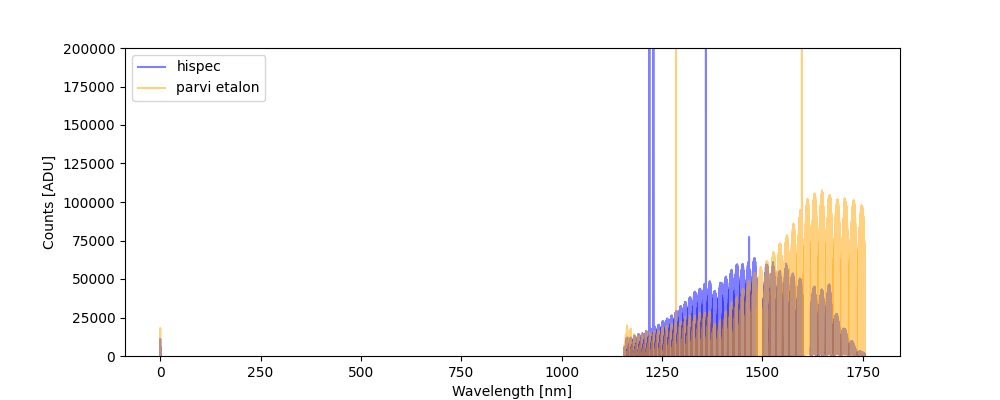

In [5]:

# plot
iorder = 23

plt.figure(figsize=(10,4))
for iorder in np.arange(44):
    if iorder ==0:
        plt.plot(waves_sci[iorder], sci[1][iorder],'blue',  alpha=0.5,label='hispec')
        plt.plot(waves_cal[iorder], cal[1][iorder],'orange', alpha=0.5, label='parvi etalon')
    else:
        plt.plot(waves_sci[iorder], sci[1][iorder],'blue', alpha=0.5)
        plt.plot(waves_cal[iorder], cal[1][iorder],'orange', alpha=0.5)

#plt.xlim(1400, 1800)
plt.ylim(0,2e5) 

plt.legend()
plt.xlabel('Wavelength [nm]')
plt.ylabel('Counts [ADU]')
